In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

In [2]:
data = load_diabetes()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Features:", data.feature_names)

Dataset Shape: (442, 10)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [3]:
X = data.data[:, 2].reshape(-1, 1)

print("Selected Feature: BMI")
print("Shape:", X.shape)

Selected Feature: BMI
Shape: (442, 1)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [5]:
degrees = [1, 2, 3, 5, 10]

train_errors = []
test_errors = []

In [6]:
for degree in degrees:

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

    print("Degree:", degree)
    print("Training MSE:", train_mse)
    print("Testing MSE:", test_mse)
    print()

Degree: 1
Training MSE: 3854.11265207582
Testing MSE: 4061.8259284949268

Degree: 2
Training MSE: 3849.333133411179
Testing MSE: 4085.025480871632

Degree: 3
Training MSE: 3848.4472378570276
Testing MSE: 4064.443383716436

Degree: 5
Training MSE: 3823.763813306945
Testing MSE: 4085.845566850978

Degree: 10
Training MSE: 3724.6126872010454
Testing MSE: 4315.533060005464



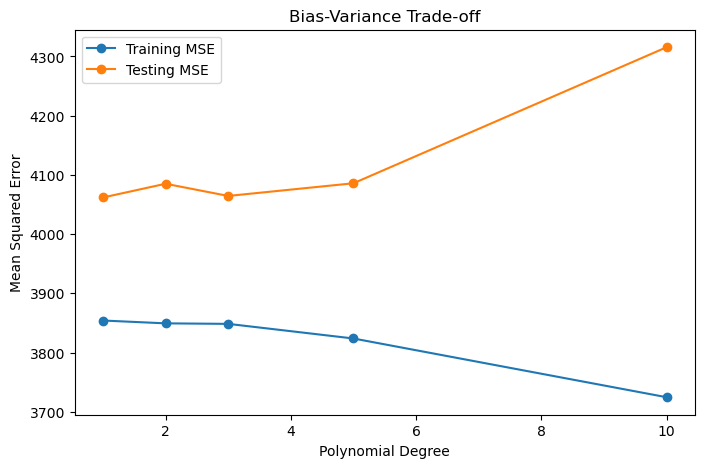

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(degrees, train_errors, marker='o', label="Training MSE")
plt.plot(degrees, test_errors, marker='o', label="Testing MSE")

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Bias-Variance Trade-off")
plt.legend()
plt.show()

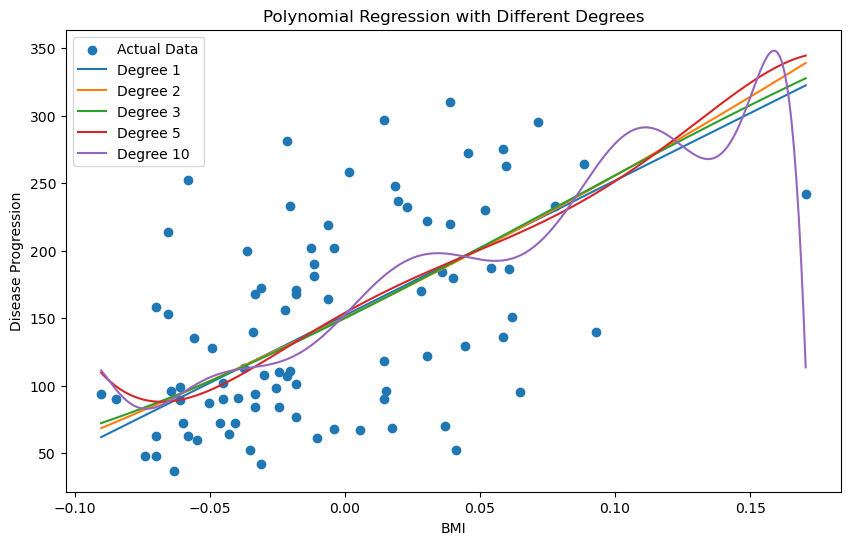

In [8]:
plt.figure(figsize=(10, 6))

plt.scatter(X_test, y_test, label="Actual Data")

x_range = np.linspace(
    X.min(),
    X.max(),
    300
).reshape(-1, 1)

for degree in degrees:

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_range_pred = model.predict(x_range)

    plt.plot(
        x_range,
        y_range_pred,
        label=f"Degree {degree}"
    )

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Polynomial Regression with Different Degrees")
plt.legend()

plt.show()